In [176]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import scipy
import time
import gget
import anndata as an
import math
import scanpy as sc
import scanpy.external as sce
import h5py
from collections import Counter
import scipy.sparse as sp
import scipy.stats as stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy.stats import spearmanr, pearsonr
from scipy.stats import kruskal

sc.settings.verbosity = 2

# Load data

In [3]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups_v2.h5ad"
bdata = sc.read_h5ad(fpath)
bdata

CPU times: user 308 ms, sys: 1.38 s, total: 1.69 s
Wall time: 3.51 s


AnnData object with n_obs × n_vars = 16296 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

In [6]:
# subset for mmMYOD1 cells
conditions = ['mmMYOD1']

adata = bdata[bdata.obs['pooled_condition'].isin(conditions), :].copy()

# re-normalize
adata.X = adata.layers['raw_counts']

sc.pp.filter_genes(adata, min_cells=20)# min_counts=10)
sc.pp.normalize_total(adata, target_sum=1e4)
adata.layers['norm'] = adata.X.copy()

sc.pp.log1p(adata)
adata.layers['log_norm'] = adata.X.copy()

adata

filtered out 6756 genes that are detected in less than 20 cells
normalizing counts per cell
    finished (0:00:00)


AnnData object with n_obs × n_vars = 2255 × 18370
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'std

In [8]:
# re-compute QC metrics to get total counts
adata.X = adata.layers['raw_counts'].copy()

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo"], inplace=True, log1p=True)
adata

AnnData object with n_obs × n_vars = 2255 × 18370
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'std

In [9]:
adata.obs['total_counts'].describe()

count     2255.000000
mean     10893.074219
std       4423.062500
min       2994.000000
25%       7596.500000
50%      10342.000000
75%      13545.000000
max      34275.000000
Name: total_counts, dtype: float64

In [102]:
layer = 'log_norm'

adata.X = adata.layers[layer].copy()

mdata = adata[:, 'MYOD1'].copy()
print(mdata.shape)


X = mdata.X if isinstance(mdata.X, np.ndarray) else mdata.X.toarray()

df = pd.DataFrame(
        X,
        index=mdata.obs_names,
        columns=mdata.var_names,
    )


df = df.reset_index(names='cell_id')
print(df.shape)

obs_cols = ['total_counts', 'n_genes_by_counts']
# obs_cols = ['log1p_total_counts', 'log1p_n_genes_by_counts']

tmp = adata.obs[obs_cols].copy()
tmp = tmp.reset_index(names='cell_id')


df = pd.merge(df, tmp, how='left', on='cell_id')
df = df.set_index('cell_id')
print(df.shape)
df.head()

(2255, 1)
(2255, 2)
(2255, 3)


,MYOD1,total_counts,n_genes_by_counts
cell_id,,,
AAACCAAAGTAGGGCA_hybrid,1.636706,9666.0,3571
AAACCCGCACCATAGG_hybrid,1.239239,12230.0,4383
AAACCCGCATCCAATT_hybrid,1.049213,16169.0,4361
AAACCCTGTAACGACA_hybrid,0.995507,17584.0,5508
AAACGGGTCGTAATGT_hybrid,0.767018,17341.0,5541


In [103]:
df['MYOD1'].describe()

count    2255.000000
mean        1.662471
std         0.800968
min         0.000000
25%         1.150628
50%         1.678359
75%         2.217715
max         3.885127
Name: MYOD1, dtype: float64

In [78]:
print("Total MYOD1 expression:")
print(f"Mean = {df['MYOD1'].mean():.4f}, Median = {df['MYOD1'].median():.4f}\n")

print("Among positive MYOD1 expression:")
print(f"Mean = {df[df['MYOD1'] > 0]['MYOD1'].mean():.4f}, Median = {df[df['MYOD1'] > 0]['MYOD1'].median():.4f}\n")

Total MYOD1 expression:
Mean = 1.6625, Median = 1.6784

Among positive MYOD1 expression:
Mean = 1.7750, Median = 1.7342



# Bin MYOD1 expression

In [98]:
# bin expression 
df1 = df.copy()

# create mask for cells that are actually expressing MYOD1
expressed_mask = df1['MYOD1'] > 0

# initialize column 
df1['MYOD1_level'] = '0'

n_bins = 5
bin_labels = [str(i) for i in range(1, n_bins + 1)] # list(range(1, n_bins+1))

# ### equal expression widths
# df1.loc[expressed_mask, 'MYOD1_level'] = pd.cut(
#     df1.loc[expressed_mask, 'MYOD1'],
#     bins=n_bins,
#     labels=bin_labels,
# )

### equal number of cells
df1.loc[expressed_mask, 'MYOD1_level'] = pd.qcut(
    df1.loc[expressed_mask, 'MYOD1'],
    q=n_bins,
    labels=bin_labels,
)


df1['MYOD1_level'] = pd.Categorical(
    df1['MYOD1_level'],
    categories=['0'] + bin_labels,
    ordered=True
)

print(df1['MYOD1_level'].value_counts())

df1.head()

MYOD1_level
1    423
5    423
3    422
2    422
4    422
0    143
Name: count, dtype: int64


,MYOD1,log1p_total_counts,log1p_n_genes_by_counts,MYOD1_level
cell_id,,,,
AAACCAAAGTAGGGCA_hybrid,1.636706,9.176474,8.180881,3
AAACCCGCACCATAGG_hybrid,1.239239,9.411729,8.385717,2
AAACCCGCATCCAATT_hybrid,1.049213,9.690913,8.380686,1
AAACCCTGTAACGACA_hybrid,0.995507,9.774801,8.614138,1
AAACGGGTCGTAATGT_hybrid,0.767018,9.760886,8.620111,1


In [99]:
for val in obs_cols:
    # Check correlation across ALL cells
    corr_all, p_all = spearmanr(df1['MYOD1'], df1[val])
    
    # Check correlation only in cells that ACTUALLY express it
    expressed = df1[df1['MYOD1'] > 0]
    corr_exp, p_exp = spearmanr(expressed['MYOD1'], expressed[val])
    
    print(f"--- {val} ---")
    print(f"All cells Spearman r: {corr_all:.3f} (p={p_all:.3e})")
    print(f"Expressing cells Spearman r: {corr_exp:.3f} (p={p_exp:.3e})\n")

--- log1p_total_counts ---
All cells Spearman r: -0.442 (p=1.832e-108)
Expressing cells Spearman r: -0.495 (p=3.344e-131)

--- log1p_n_genes_by_counts ---
All cells Spearman r: -0.304 (p=2.740e-49)
Expressing cells Spearman r: -0.359 (p=3.653e-65)



In [100]:
for val in obs_cols:
    # Group the sequencing depth data by your categories
    groups = [group[val].values for name, group in df1.groupby('MYOD1_level', observed=True)]
    
    # Run Kruskal-Wallis H-test
    H_stat, p_val = kruskal(*groups)
    
    # Calculate Eta-Squared for Kruskal-Wallis
    # Formula: eta^2 = (H - k + 1) / (n - k)
    n = len(df1)
    k = len(groups)
    eta_sq = (H_stat - k + 1) / (n - k)
    
    print(f"--- {val} across MYOD1 Bins ---")
    print(f"Kruskal H-statistic: {H_stat:.2f} (p={p_val:.3e})")
    print(f"Eta-squared (\u03b7\u00b2): {eta_sq:.4f} ({eta_sq*100:.2f}% of variance explained)\n")

--- log1p_total_counts across MYOD1 Bins ---
Kruskal H-statistic: 547.02 (p=5.635e-116)
Eta-squared (η²): 0.2410 (24.10% of variance explained)

--- log1p_n_genes_by_counts across MYOD1 Bins ---
Kruskal H-statistic: 314.04 (p=9.603e-66)
Eta-squared (η²): 0.1374 (13.74% of variance explained)



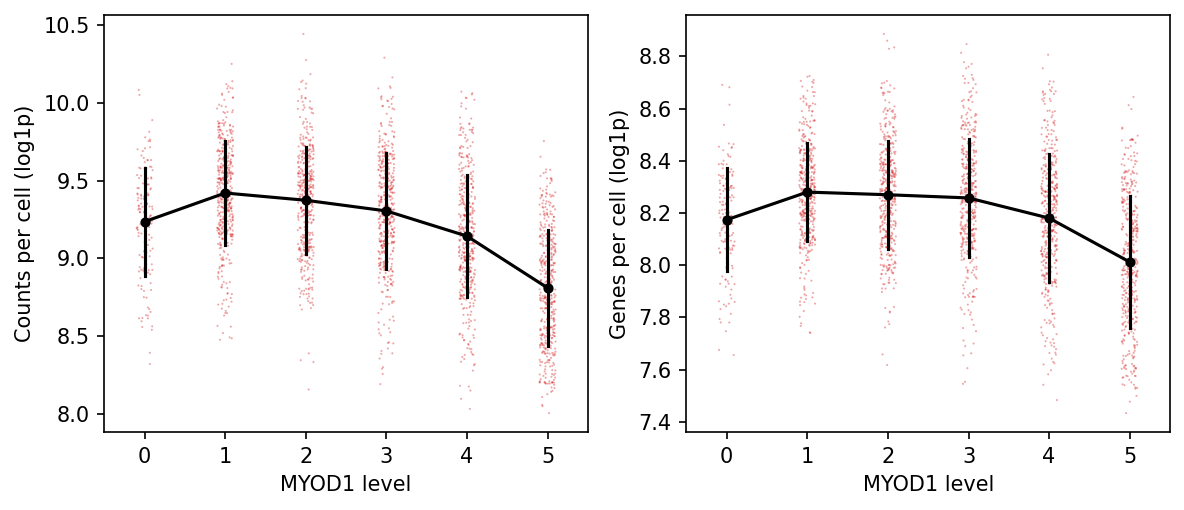

In [101]:
# import logging
# logging.getLogger("matplotlib.category").setLevel(logging.WARNING)

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), dpi=150)
axes = axes.flatten()

# vals_to_plot = ['total_counts', 'n_genes_by_counts']

for i, val in enumerate(obs_cols):
    ax = axes[i]
    sns.stripplot(
        data=df1, 
        x="MYOD1_level", 
        y=val,
        alpha=.4, 
        legend=False, 
        s=1,
        edgecolor='none',
        ax=ax,
        color='tab:red',
        zorder=0,
    )
    sns.pointplot(
        df1,
        x='MYOD1_level',
        y=val,
        errorbar='sd',
        linewidth=1.5,
        color='k',
        ax=ax,
    )
    
    ax.set_xlabel('MYOD1 level')

    
# axes[0].set_ylabel('Counts per cell')
# axes[1].set_ylabel('Genes per cell')

axes[0].set_ylabel('Counts per cell (log1p)')
axes[1].set_ylabel('Genes per cell (log1p)')
    
plt.tight_layout()  
plt.show()

# Renormalize

In [107]:
layer = 'raw_counts'

adata.X = adata.layers[layer].copy()

mdata = adata[:, 'MYOD1'].copy()
print(mdata.shape)


X = mdata.X if isinstance(mdata.X, np.ndarray) else mdata.X.toarray()

df = pd.DataFrame(
        X,
        index=mdata.obs_names,
        columns=mdata.var_names,
    )


df = df.reset_index(names='cell_id')
print(df.shape)

obs_cols = ['total_counts', 'n_genes_by_counts']
# obs_cols = ['log1p_total_counts', 'log1p_n_genes_by_counts']

tmp = adata.obs[obs_cols].copy()
tmp = tmp.reset_index(names='cell_id')


df = pd.merge(df, tmp, how='left', on='cell_id')
df = df.set_index('cell_id')

df = df.rename(columns={'MYOD1': 'MYOD1_raw'})

print(df.shape)
df.head()

(2255, 1)
(2255, 2)
(2255, 3)


,MYOD1_raw,total_counts,n_genes_by_counts
cell_id,,,
AAACCAAAGTAGGGCA_hybrid,4.0,9666.0,3571
AAACCCGCACCATAGG_hybrid,3.0,12230.0,4383
AAACCCGCATCCAATT_hybrid,3.0,16169.0,4361
AAACCCTGTAACGACA_hybrid,3.0,17584.0,5508
AAACGGGTCGTAATGT_hybrid,2.0,17341.0,5541


In [110]:
df['endogenous_counts'] = df['total_counts'] - df['MYOD1_raw']

# re-calculate normalized MYOD1 based on new baseline
df['MYOD1'] = (df['MYOD1_raw'] / df['endogenous_counts']) * 10000
df['MYOD1'] = df['MYOD1'].apply(np.log1p)

df.head()

,MYOD1_raw,total_counts,n_genes_by_counts,endogenous_counts,MYOD1
cell_id,,,,,
AAACCAAAGTAGGGCA_hybrid,4.0,9666.0,3571,9662.0,1.637039
AAACCCGCACCATAGG_hybrid,3.0,12230.0,4383,12227.0,1.239413
AAACCCGCATCCAATT_hybrid,3.0,16169.0,4361,16166.0,1.049333
AAACCCTGTAACGACA_hybrid,3.0,17584.0,5508,17581.0,0.995615
AAACGGGTCGTAATGT_hybrid,2.0,17341.0,5541,17339.0,0.767080


In [111]:
df['MYOD1'].describe()

count    2255.000000
mean        1.663015
std         0.801489
min         0.000000
25%         1.150776
50%         1.678713
75%         2.218445
max         3.889807
Name: MYOD1, dtype: float64

In [112]:
print("Total MYOD1 expression:")
print(f"Mean = {df['MYOD1'].mean():.4f}, Median = {df['MYOD1'].median():.4f}\n")

print("Among positive MYOD1 expression:")
print(f"Mean = {df[df['MYOD1'] > 0]['MYOD1'].mean():.4f}, Median = {df[df['MYOD1'] > 0]['MYOD1'].median():.4f}\n")

Total MYOD1 expression:
Mean = 1.6630, Median = 1.6787

Among positive MYOD1 expression:
Mean = 1.7756, Median = 1.7345



In [113]:
# bin expression 
df1 = df.copy()

# create mask for cells that are actually expressing MYOD1
expressed_mask = df1['MYOD1'] > 0

# initialize column 
df1['MYOD1_level'] = '0'

n_bins = 5
bin_labels = [str(i) for i in range(1, n_bins + 1)] # list(range(1, n_bins+1))


### equal number of cells
df1.loc[expressed_mask, 'MYOD1_level'] = pd.qcut(
    df1.loc[expressed_mask, 'MYOD1'],
    q=n_bins,
    labels=bin_labels,
)


df1['MYOD1_level'] = pd.Categorical(
    df1['MYOD1_level'],
    categories=['0'] + bin_labels,
    ordered=True
)

print(df1['MYOD1_level'].value_counts())

df1.head()

MYOD1_level
1    423
5    423
3    422
2    422
4    422
0    143
Name: count, dtype: int64


,MYOD1_raw,total_counts,n_genes_by_counts,endogenous_counts,MYOD1,MYOD1_level
cell_id,,,,,,
AAACCAAAGTAGGGCA_hybrid,4.0,9666.0,3571,9662.0,1.637039,3
AAACCCGCACCATAGG_hybrid,3.0,12230.0,4383,12227.0,1.239413,2
AAACCCGCATCCAATT_hybrid,3.0,16169.0,4361,16166.0,1.049333,1
AAACCCTGTAACGACA_hybrid,3.0,17584.0,5508,17581.0,0.995615,1
AAACGGGTCGTAATGT_hybrid,2.0,17341.0,5541,17339.0,0.767080,1


In [114]:
for val in obs_cols + ['endogenous_counts']:
    # Check correlation across ALL cells
    corr_all, p_all = spearmanr(df1['MYOD1'], df1[val])
    
    # Check correlation only in cells that ACTUALLY express it
    expressed = df1[df1['MYOD1'] > 0]
    corr_exp, p_exp = spearmanr(expressed['MYOD1'], expressed[val])
    
    print(f"--- {val} ---")
    print(f"All cells Spearman r: {corr_all:.3f} (p={p_all:.3e})")
    print(f"Expressing cells Spearman r: {corr_exp:.3f} (p={p_exp:.3e})\n")

--- total_counts ---
All cells Spearman r: -0.442 (p=1.835e-108)
Expressing cells Spearman r: -0.495 (p=3.352e-131)

--- n_genes_by_counts ---
All cells Spearman r: -0.304 (p=2.743e-49)
Expressing cells Spearman r: -0.359 (p=3.658e-65)

--- endogenous_counts ---
All cells Spearman r: -0.443 (p=6.577e-109)
Expressing cells Spearman r: -0.496 (p=1.140e-131)



In [120]:
rho, p = spearmanr(df1['total_counts'], df1['endogenous_counts'])
print(f'{rho:.3f}', f'{p:.3e}')

r, p = pearsonr(df1['total_counts'], df1['endogenous_counts'])
print(f'{r:.3f}', f'{p:.3e}')

1.000 0.000e+00
1.000 0.000e+00


In [115]:
for val in obs_cols + ['endogenous_counts']:
    # Group the sequencing depth data by your categories
    groups = [group[val].values for name, group in df1.groupby('MYOD1_level', observed=True)]
    
    # Run Kruskal-Wallis H-test
    H_stat, p_val = kruskal(*groups)
    
    # Calculate Eta-Squared for Kruskal-Wallis
    # Formula: eta^2 = (H - k + 1) / (n - k)
    n = len(df1)
    k = len(groups)
    eta_sq = (H_stat - k + 1) / (n - k)
    
    print(f"--- {val} across MYOD1 Bins ---")
    print(f"Kruskal H-statistic: {H_stat:.2f} (p={p_val:.3e})")
    print(f"Eta-squared (\u03b7\u00b2): {eta_sq:.4f} ({eta_sq*100:.2f}% of variance explained)\n")

--- total_counts across MYOD1 Bins ---
Kruskal H-statistic: 547.02 (p=5.635e-116)
Eta-squared (η²): 0.2410 (24.10% of variance explained)

--- n_genes_by_counts across MYOD1 Bins ---
Kruskal H-statistic: 314.04 (p=9.603e-66)
Eta-squared (η²): 0.1374 (13.74% of variance explained)

--- endogenous_counts across MYOD1 Bins ---
Kruskal H-statistic: 548.66 (p=2.489e-116)
Eta-squared (η²): 0.2417 (24.17% of variance explained)



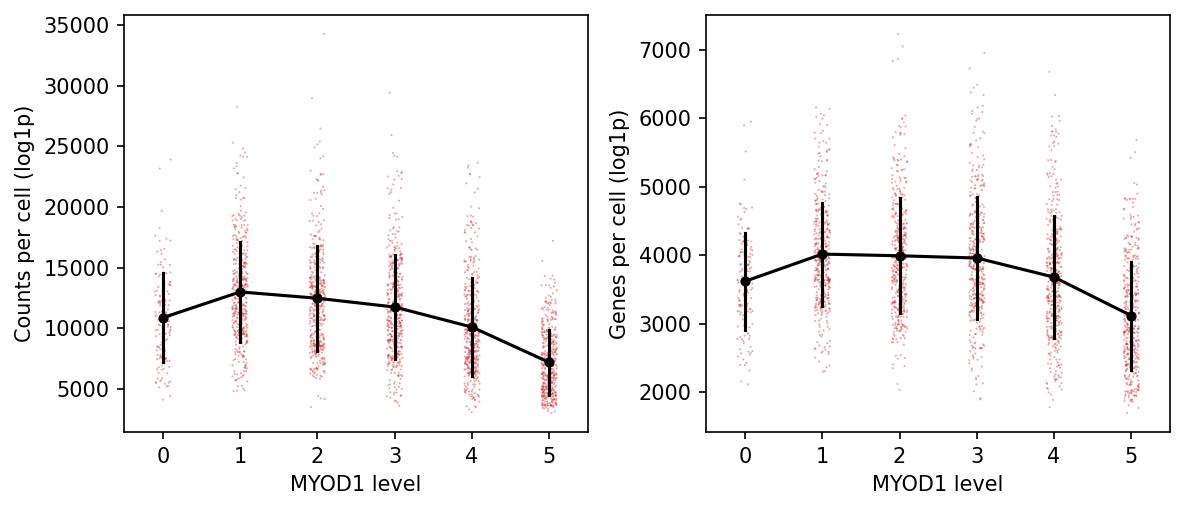

In [116]:
# import logging
# logging.getLogger("matplotlib.category").setLevel(logging.WARNING)

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), dpi=150)
axes = axes.flatten()

vals_to_plot = ['endogenous_counts', 'n_genes_by_counts']

for i, val in enumerate(obs_cols):
    ax = axes[i]
    sns.stripplot(
        data=df1, 
        x="MYOD1_level", 
        y=val,
        alpha=.4, 
        legend=False, 
        s=1,
        edgecolor='none',
        ax=ax,
        color='tab:red',
        zorder=0,
    )
    sns.pointplot(
        df1,
        x='MYOD1_level',
        y=val,
        errorbar='sd',
        linewidth=1.5,
        color='k',
        ax=ax,
    )
    
    ax.set_xlabel('MYOD1 level')

    
# axes[0].set_ylabel('Counts per cell')
# axes[1].set_ylabel('Genes per cell')

axes[0].set_ylabel('Counts per cell (log1p)')
axes[1].set_ylabel('Genes per cell (log1p)')
    
plt.tight_layout()  
plt.show()

In [121]:
df1.head()

,MYOD1_raw,total_counts,n_genes_by_counts,endogenous_counts,MYOD1,MYOD1_level
cell_id,,,,,,
AAACCAAAGTAGGGCA_hybrid,4.0,9666.0,3571,9662.0,1.637039,3
AAACCCGCACCATAGG_hybrid,3.0,12230.0,4383,12227.0,1.239413,2
AAACCCGCATCCAATT_hybrid,3.0,16169.0,4361,16166.0,1.049333,1
AAACCCTGTAACGACA_hybrid,3.0,17584.0,5508,17581.0,0.995615,1
AAACGGGTCGTAATGT_hybrid,2.0,17341.0,5541,17339.0,0.767080,1


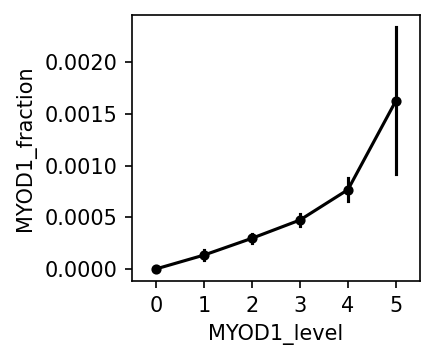

In [122]:
df1['MYOD1_fraction'] = df1['MYOD1_raw'] / df1['total_counts']

plt.figure(figsize=(3,2.5), dpi=150)

sns.pointplot(
    df1,
    x='MYOD1_level',
    y='MYOD1_fraction',
    errorbar='sd',
    linewidth=1.5,
    color='k',
)

plt.tight_layout()  
plt.show()

In [123]:
df1['MYOD1_fraction'].describe()

count    2255.000000
mean        0.000618
std         0.000620
min         0.000000
25%         0.000216
50%         0.000436
75%         0.000819
max         0.004767
Name: MYOD1_fraction, dtype: float64

In [132]:
rho, p = spearmanr(df1['MYOD1_raw'], df1['endogenous_counts'])
print(f'{rho:.3f}', f'{p:.3e}')

pos_df1 = df1[df1['MYOD1_raw'] > 0]
rho, p = spearmanr(pos_df1['MYOD1_raw'], pos_df1['endogenous_counts'])
print(f'{rho:.3f}', f'{p:.3e}')

rho, p = spearmanr(df1['MYOD1_raw'], df1['total_counts'])
print(f'{rho:.3f}', f'{p:.3e}')

pos_df1 = df1[df1['MYOD1_raw'] > 0]
rho, p = spearmanr(pos_df1['MYOD1_raw'], pos_df1['total_counts'])
print(f'{rho:.3f}', f'{p:.3e}')

-0.030 1.530e-01
-0.029 1.856e-01
-0.029 1.661e-01
-0.028 1.997e-01


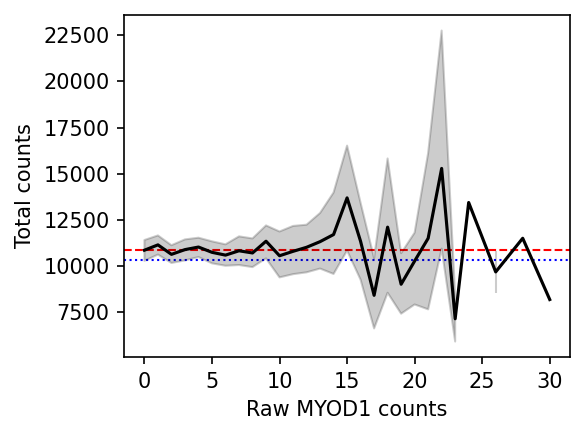

In [136]:
plt.figure(figsize=(4,3), dpi=150)

y_val = 'total_counts'

mean = df1[y_val].mean()
median = df1[y_val].median()

sns.lineplot(
    df1,
    x='MYOD1_raw',
    y='total_counts',
    # errorbar='sd',
    linewidth=1.5,
    color='k',
)

plt.axhline(mean, ls='--', color='red', lw=1, zorder=0)
plt.axhline(median, ls=':', color='blue', lw=1, zorder=0)

plt.xlabel('Raw MYOD1 counts')
plt.ylabel('Total counts')

plt.tight_layout()  
plt.show()

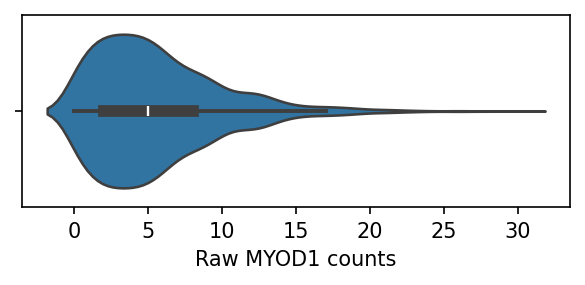

In [148]:
plt.figure(figsize=(4,2), dpi=150)

sns.violinplot(
    df1,
    x='MYOD1_raw',
    # y='total_counts',
    # errorbar='sd',
    # linewidth=1.5,
    # color='k',
)

# plt.axhline(mean, ls='--', color='red', lw=1, zorder=0)
# plt.axhline(median, ls=':', color='blue', lw=1, zorder=0)

plt.xlabel('Raw MYOD1 counts')
# plt.ylabel('Total counts')

plt.tight_layout()  
plt.show()

In [152]:
# try binning on raw counts
# create mask for cells that are actually expressing MYOD1
expressed_mask = df1['MYOD1_raw'] > 0

# initialize column 
df1['MYOD1_level'] = '0'

n_bins = 5
bin_labels = [str(i) for i in range(1, n_bins + 1)] # list(range(1, n_bins+1))


# ### equal number of cells
# df1.loc[expressed_mask, 'MYOD1_level'] = pd.qcut(
#     df1.loc[expressed_mask, 'MYOD1_raw'],
#     q=n_bins,
#     labels=bin_labels,
#     duplicates='drop', # handled overlapping bin edges; if edges overlap itll group into less bins
# )

# 1. Run qcut with retbins=True
binned_series, bin_edges = pd.qcut(
    df1.loc[expressed_mask, 'MYOD1_raw'],
    q=n_bins,
    labels=bin_labels,
    duplicates='drop',
    retbins=True       # <-- This returns the edges as a second variable
)

# 2. Assign the series to your dataframe just like before
df1.loc[expressed_mask, 'MYOD1_level'] = binned_series

# 3. Print the edges to see your thresholds
print("Calculated Bin Edges:")
print(bin_edges)


df1['MYOD1_level'] = pd.Categorical(
    df1['MYOD1_level'],
    categories=['0'] + bin_labels,
    ordered=True
)

print(df1['MYOD1_level'].value_counts())
df1.head()

Calculated Bin Edges:
[ 1.  2.  4.  6.  9. 30.]
MYOD1_level
2    489
1    454
3    433
4    384
5    352
0    143
Name: count, dtype: int64


,MYOD1_raw,total_counts,n_genes_by_counts,endogenous_counts,MYOD1,MYOD1_level,MYOD1_fraction
cell_id,,,,,,,
AAACCAAAGTAGGGCA_hybrid,4.0,9666.0,3571,9662.0,1.637039,2,0.000414
AAACCCGCACCATAGG_hybrid,3.0,12230.0,4383,12227.0,1.239413,2,0.000245
AAACCCGCATCCAATT_hybrid,3.0,16169.0,4361,16166.0,1.049333,2,0.000186
AAACCCTGTAACGACA_hybrid,3.0,17584.0,5508,17581.0,0.995615,2,0.000171
AAACGGGTCGTAATGT_hybrid,2.0,17341.0,5541,17339.0,0.767080,1,0.000115


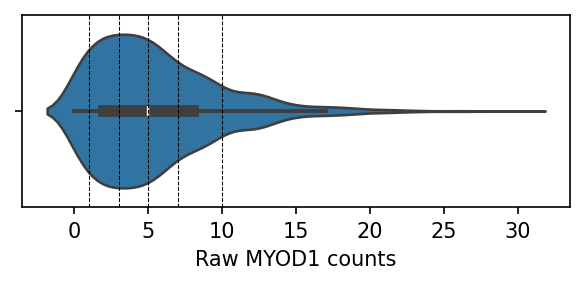

In [154]:
plt.figure(figsize=(4,2), dpi=150)

sns.violinplot(
    df1,
    x='MYOD1_raw',
)


bin_edges = [1, 3, 5, 7, 10]
for edge in bin_edges:
    plt.axvline(edge, ls='--', color='k', lw=0.5)

plt.xlabel('Raw MYOD1 counts')
# plt.ylabel('Total counts')

plt.tight_layout()  
plt.show()

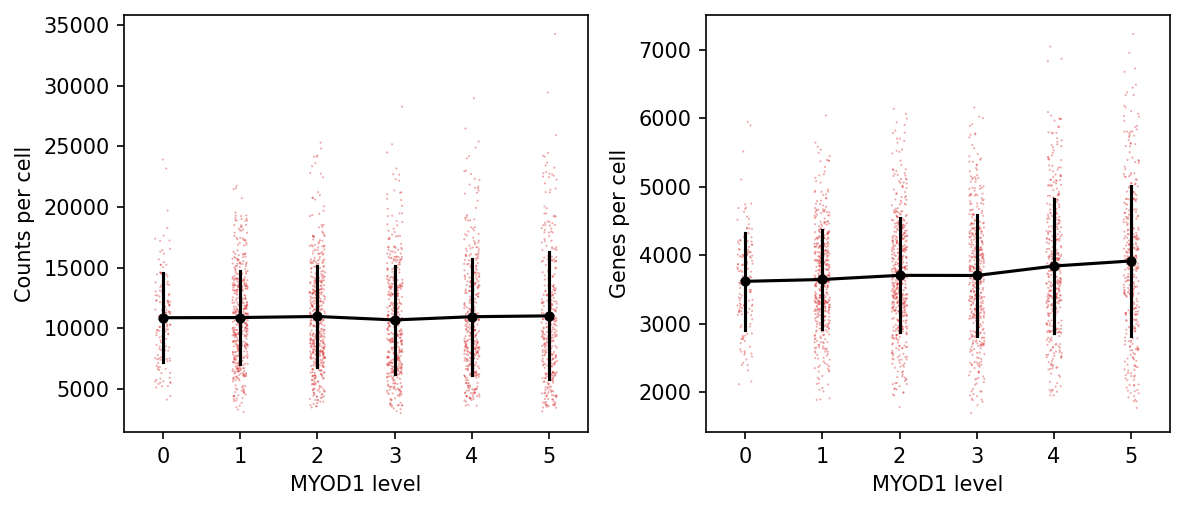

In [153]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), dpi=150)
axes = axes.flatten()

vals_to_plot = ['endogenous_counts', 'n_genes_by_counts']

for i, val in enumerate(obs_cols):
    ax = axes[i]
    sns.stripplot(
        data=df1, 
        x="MYOD1_level", 
        y=val,
        alpha=.4, 
        legend=False, 
        s=1,
        edgecolor='none',
        ax=ax,
        color='tab:red',
        zorder=0,
    )
    sns.pointplot(
        df1,
        x='MYOD1_level',
        y=val,
        errorbar='sd',
        linewidth=1.5,
        color='k',
        ax=ax,
    )
    
    ax.set_xlabel('MYOD1 level')

    
axes[0].set_ylabel('Counts per cell')
axes[1].set_ylabel('Genes per cell')

# axes[0].set_ylabel('Counts per cell (log1p)')
# axes[1].set_ylabel('Genes per cell (log1p)')
    
plt.tight_layout()  
plt.show()

In [144]:
rho, p = spearmanr(df1['MYOD1_level'], df1['n_genes_by_counts'])
print(f'{rho:.3f}', f'{p:.3e}')

pos_df1 = df1[df1['MYOD1_raw'] > 0]
rho, p = spearmanr(pos_df1['MYOD1_level'], pos_df1['n_genes_by_counts'])
print(f'{rho:.3f}', f'{p:.3e}')

0.086 4.414e-05
0.082 1.524e-04


In [149]:
df1.head()

,MYOD1_raw,total_counts,n_genes_by_counts,endogenous_counts,MYOD1,MYOD1_level,MYOD1_fraction
cell_id,,,,,,,
AAACCAAAGTAGGGCA_hybrid,4.0,9666.0,3571,9662.0,1.637039,2,0.000414
AAACCCGCACCATAGG_hybrid,3.0,12230.0,4383,12227.0,1.239413,2,0.000245
AAACCCGCATCCAATT_hybrid,3.0,16169.0,4361,16166.0,1.049333,2,0.000186
AAACCCTGTAACGACA_hybrid,3.0,17584.0,5508,17581.0,0.995615,2,0.000171
AAACGGGTCGTAATGT_hybrid,2.0,17341.0,5541,17339.0,0.767080,1,0.000115


In [151]:
df1[df1['MYOD1_level'] == '5']['MYOD1_raw'].describe()

count    352.000000
mean      13.258523
std        3.376420
min       10.000000
25%       11.000000
50%       12.000000
75%       14.250000
max       30.000000
Name: MYOD1_raw, dtype: float64

# Final bins

In [160]:
layer = 'raw_counts'

adata.X = adata.layers[layer].copy()

mdata = adata[:, 'MYOD1'].copy()
print(mdata.shape)


X = mdata.X if isinstance(mdata.X, np.ndarray) else mdata.X.toarray()

df = pd.DataFrame(
        X,
        index=mdata.obs_names,
        columns=mdata.var_names,
    )

df.index.name = None
df.columns.name = None

print(df.shape)
df.head()

(2255, 1)
(2255, 1)


,MYOD1
AAACCAAAGTAGGGCA_hybrid,4.0
AAACCCGCACCATAGG_hybrid,3.0
AAACCCGCATCCAATT_hybrid,3.0
AAACCCTGTAACGACA_hybrid,3.0
AAACGGGTCGTAATGT_hybrid,2.0


In [163]:
# create mask for cells that are actually expressing MYOD1
expressed_mask = df['MYOD1'] > 0

# initialize column 
df['MYOD1_level'] = '0'

n_bins = 5
bin_labels = [str(i) for i in range(1, n_bins + 1)] # list(range(1, n_bins+1))


# ### equal number of cells
binned_series, bin_edges = pd.qcut(
    df.loc[expressed_mask, 'MYOD1'],
    q=n_bins,
    labels=bin_labels,
    duplicates='drop',
    retbins=True       # <-- This returns the edges as a second variable
)

# 2. Assign the series to your dataframe just like before
df.loc[expressed_mask, 'MYOD1_level'] = binned_series

# 3. Print the edges to see your thresholds
print("Calculated Bin Edges:")
print(bin_edges)

df['MYOD1_level'] = pd.Categorical(
    df['MYOD1_level'],
    categories=['0'] + bin_labels,
    ordered=True
)

print(df['MYOD1_level'].value_counts())
df.head()

Calculated Bin Edges:
[ 1.  2.  4.  6.  9. 30.]
MYOD1_level
2    489
1    454
3    433
4    384
5    352
0    143
Name: count, dtype: int64


,MYOD1,MYOD1_level
AAACCAAAGTAGGGCA_hybrid,4.0,2
AAACCCGCACCATAGG_hybrid,3.0,2
AAACCCGCATCCAATT_hybrid,3.0,2
AAACCCTGTAACGACA_hybrid,3.0,2
AAACGGGTCGTAATGT_hybrid,2.0,1


## add back to adata

In [164]:
adata.obs = adata.obs.join(df[['MYOD1_level']])

print(adata.shape)
adata.obs.head()

(2255, 18370)


,MYOD-fb_counts,PRRX1-fb_counts,PRRX1_MYOD-fb_counts,assigned_condition,total_fb_counts,condition_counts_rate,G1-fb_counts,G2M-fb_counts,S-fb_counts,dataset,...,n_genes,doublet_score,predicted_doublet,S_score,G2M_score,phase,leiden,cluster_str,leiden_split,MYOD1_level
AAACCAAAGTAGGGCA_hybrid,14.0,1.0,1.0,MYOD,16.0,0.875000,NaN,NaN,NaN,Hybrid,...,3584,0.186876,False,0.393597,-0.038824,S,0,C1,M1,2
AAACCCGCACCATAGG_hybrid,22.0,0.0,1.0,MYOD,23.0,0.956522,NaN,NaN,NaN,Hybrid,...,4407,0.166452,False,-0.397221,-0.635882,G1,0,C1,M2,2
AAACCCGCATCCAATT_hybrid,22.0,2.0,1.0,MYOD,25.0,0.880000,NaN,NaN,NaN,Hybrid,...,4374,0.042910,False,0.167261,4.090784,G2M,0,C1,M1,2
AAACCCTGTAACGACA_hybrid,24.0,0.0,1.0,MYOD,25.0,0.960000,NaN,NaN,NaN,Hybrid,...,5556,0.227119,False,-0.689339,0.019020,G2M,0,C1,M2,2
AAACGGGTCGTAATGT_hybrid,25.0,0.0,0.0,MYOD,25.0,1.000000,NaN,NaN,NaN,Hybrid,...,5569,0.069588,False,-0.053156,2.836667,G2M,1,C2,M1,1


# Gene expression

# Score gene sets

In [179]:
### GO biological processes
path_2023 = "../resources/GO_Biological_Process_2023.txt"
path_2025 = "/home/jrcwycy/.cache/gseapy/Enrichr.GO_Biological_Process_2025.gmt"

geneset_dict = {}

with open(path_2025, "r") as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 1:
            term = parts[0].strip()
            genes = parts[2:] if len(parts) > 2 else []
            genes = [g.strip() for g in genes if g.strip()]
            geneset_dict[term] = genes

geneset = pd.DataFrame.from_dict(geneset_dict, orient='index').T
geneset.head()

,'De Novo' AMP Biosynthetic Process (GO:0044208),'De Novo' Post-Translational Protein Folding (GO:0051084),2-Oxoglutarate Metabolic Process (GO:0006103),3'-UTR-mediated mRNA Destabilization (GO:0061158),3'-UTR-mediated mRNA Stabilization (GO:0070935),3'-Phosphoadenosine 5'-Phosphosulfate Metabolic Process (GO:0050427),4-Hydroxyproline Metabolic Process (GO:0019471),5S Class rRNA Transcription by RNA Polymerase III (GO:0042791),7-Methylguanosine RNA Capping (GO:0009452),7-Methylguanosine Cap Hypermethylation (GO:0036261),...,Wybutosine Biosynthetic Process (GO:0031591),Wybutosine Metabolic Process (GO:0031590),Xenobiotic Catabolic Process (GO:0042178),Xenobiotic Transport (GO:0042908),Xenobiotic Transport Across Blood-Brain Barrier (GO:1990962),Zinc Ion Import Across Plasma Membrane (GO:0071578),Zinc Ion Import Into Organelle (GO:0062111),Zinc Ion Transmembrane Transport (GO:0071577),Zinc Ion Transport (GO:0006829),Zymogen Activation (GO:0031638)
0,ATIC,CCT4,IDH1,UPF1,RBM38,PAPSS1,EGLN2,GTF3C2,RNGTT,SNRPD3,...,TYW5,TYW5,UGT1A10,ABCC5,ABCC2,SLC30A8,SLC30A8,SLC30A8,SLC30A8,FGB
1,PAICS,SDF2L1,PHYH,TRIM71,DAZ4,PAPSS2,GOT2,GTF3C3,RNMT,SNRPD2,...,TYW3,TYW3,GSTM4,SLC22A4,SLC22A1,SLC39A10,SLC30A7,SLC39A1,SLC39A1,FGG
2,PFAS,CCT3,GOT2,RC3H1,TIRAP,SULT1A2,HOGA1,GTF3C4,NCBP1,SNRPF,...,TYW1,TYW1,GSTM3,ABCB1,SLC22A2,SLC39A12,SLC30A4,SLC30A4,SLC30A9,F12
3,ADSS1,HSPA9,IDH2,ZFP36L1,DAZ3,SULT1C4,P4HB,GTF3C5,CMTR2,SNRPG,...,TRMT12,TRMT12,GSTM2,ABCC2,ABCC1,SLC39A6,SLC30A3,SLC30A3,SLC30A4,ZNF160
4,ADSS2,CCT2,ADHFE1,PUM2,YBX3,SULT2A1,PRODH,GTF3C6,RAMAC,SNRPE,...,TYW1B,TYW1B,NANOS1,SLC15A2,ABCG2,SLC39A14,SLC30A6,SLC30A5,SLC30A3,F9


In [180]:
### ---- Oxidative stress ----
oxi_stress_terms = [
    'Cellular Response to Oxidative Stress (GO:0034599)',
    'Regulation of Response to Oxidative Stress (GO:1902882)',
    'Regulation of Cellular Response to Oxidative Stress (GO:1900407)',
]
oxi_stress_genes = list(set(geneset[oxi_stress_terms].stack().tolist()))
print(f'N oxidative stress genes: {len(oxi_stress_genes)}')


### ---- ER stress ----
er_stress_terms = [
    'Positive Regulation of Response to Endoplasmic Reticulum Stress (GO:1905898)',
    'Response to Endoplasmic Reticulum Stress (GO:0034976)',
    'Regulation of Translation in Response to Endoplasmic Reticulum Stress (GO:0036490)',
    'Regulation of Response to Endoplasmic Reticulum Stress (GO:1905897)',
]
er_stress_genes = list(set(geneset[er_stress_terms].stack().tolist()))
print(f'N ER stress genes: {len(er_stress_genes)}')


### ---- general stress ----
stress_terms = [
    'Regulation of Cellular Response to Stress (GO:0080135)',
    'Regulation of Response to Stress (GO:0080134)',
    'Positive Regulation of Translation in Response to Stress (GO:0032056)',
]
stress_genes = list(set(geneset[stress_terms].stack().tolist()))
print(f'N ER stress genes: {len(stress_genes)}')


### ---- integrated stress response ----
isr_genes = list(set(geneset[['Integrated Stress Response Signaling (GO:0140467)']].stack().tolist()))
print(f'N integrated stress response genes: {len(isr_genes)}')


### ---- positive apoptosis ----  
pos_apop_terms = [
    'Positive Regulation of Apoptotic Cell Clearance (GO:2000427)',
    'Positive Regulation of Apoptotic Process (GO:0043065)',
    'Positive Regulation of Apoptotic Signaling Pathway (GO:2001235)',
    '+ Reg of Endoplasmic Reticulum Stress-Induced Intrinsic Apoptotic Sgnlng Pway (GO:1902237)',
    'Positive Regulation of Extrinsic Apoptotic Signaling Pathway (GO:2001238)',
    'Positive Regulation of Fibroblast Apoptotic Process (GO:2000271)',
    'Positive Regulation of Intrinsic Apoptotic Signaling Pathway (GO:2001244)',
    'Positive Regulation of Intrinsic Apoptotic Signaling Pathway by P53 Class Mediator (GO:1902255)',
    'Positive Regulation of Execution Phase of Apoptosis (GO:1900119)',
]
df = geneset[pos_apop_terms]
pos_apop_genes = list(set(df.stack().tolist()))
print(f"N pos apoptosis genes: {len(pos_apop_genes)}\n")


### ---- DNA damage response (DDR) ---- 
ddr_terms = [
    'DNA Damage Response (GO:0006974)',
    'DNA Damage Response, Signal Transduction by P53 Class Mediator (GO:0030330)',
    'Positive Regulation of DNA Damage Response, Signal Transduction by P53 Class Mediator (GO:0043517)',
    'Regulation of DNA Damage Response, Signal Transduction by P53 Class Mediator (GO:0043516)',
]

ddr_genes = list(set(geneset[ddr_terms].stack().tolist()))
print(f'N DNA damage response genes: {len(ddr_genes)}')



### skeletal muscle
cols_to_keep = [col for col in geneset if 'skeletal muscle' in col.lower()]

skel_mus_genes = list(set(geneset[cols_to_keep].stack().tolist()))
print(f'N skeletal muscle genes: {len(skel_mus_genes)}')

N oxidative stress genes: 134
N ER stress genes: 218
N ER stress genes: 121
N integrated stress response genes: 34
N pos apoptosis genes: 365

N DNA damage response genes: 468
N skeletal muscle genes: 98


In [167]:
mdf = pd.read_json("../../resources/HALLMARK_MYOGENESIS.v2026.1.Hs.json")
myogenesis = mdf.loc['geneSymbols', 'HALLMARK_MYOGENESIS']
print(f'Total HALLMARK_MYOGENESIS genes: {len(myogenesis)}')



ppdf = pd.read_json("../../resources/HALLMARK_P53_PATHWAY.v2026.1.Hs.json")
p53_genes = ppdf.loc['geneSymbols', 'HALLMARK_P53_PATHWAY']
print(f'Total HALLMARK_P53_PATHWAY genes: {len(p53_genes)}')


rdf = pd.read_json("../../resources/HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY.v2026.1.Hs.json")
ros_genes = rdf.loc['geneSymbols', 'HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY']
print(f'Total HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY genes: {len(ros_genes)}')


udf = pd.read_json("../../resources/HALLMARK_UNFOLDED_PROTEIN_RESPONSE.v2026.1.Hs.json")
upr_genes = udf.loc['geneSymbols', 'HALLMARK_UNFOLDED_PROTEIN_RESPONSE']
print(f'Total HALLMARK_UNFOLDED_PROTEIN_RESPONSE genes: {len(upr_genes)}')

Total HALLMARK_MYOGENESIS genes: 200
Total HALLMARK_P53_PATHWAY genes: 200
Total HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY genes: 49
Total HALLMARK_UNFOLDED_PROTEIN_RESPONSE genes: 113


In [182]:
fpath = "../../resources/genes_for_scoring.csv"

df = pd.read_csv(fpath)
print(df.shape)
print(df.columns.tolist())
df.head()

qui_tfs = df['quiescence'].unique()
print(f"\nN quiescence TFs: {len(qui_tfs)}")

sasp_genes = df['sasp'].unique()
print(f"N SASP genes: {len(sasp_genes)}")

(512, 18)
['G1/S_transition', 'G2/M_transition', 'CC_checkpoints', 'Cell_cycle_reg', 'Pos_proliferation', 'Neg_proliferation', 'quiescence', 'AS', 'Chromatin', 'Circadian', 'Core_repro', 'NOTCH_signaling', 'Asymm_PCP', 'FOXO', 'p53_acyivity', 'DREAM/negE2F', 'senes_stress', 'sasp']

N quiescence TFs: 60
N SASP genes: 82


In [183]:
sdf = pd.read_csv("../../resources/CellAge_senescence_signature.csv")
print(sdf.shape)
sdf.head()

sen_over = sdf[sdf['Expression'] == 'Over-expressed']['Symbol'].unique()
print(f'N over-expressed senescence genes: {len(sen_over)}')

sen_under = sdf[sdf['Expression'] == 'Under-expressed']['Symbol'].unique()
print(f'N under-expressed senescence genes: {len(sen_under)}')

(1259, 5)
N over-expressed senescence genes: 525
N under-expressed senescence genes: 734


In [184]:
fpath = "../../resources/quiescence_markers.csv"

qdf = pd.read_csv(fpath)
print(qdf.shape)
qdf.head()

print(qdf['source'].value_counts())

# remove these genes because specific to stem cell quiescence ? 
qdf = qdf[qdf['source'] != 'Cheung_down']
qdf = qdf[qdf['source'] != 'Cheung_up']

qdf_up = qdf[qdf['source'].str.endswith('_up')]
qui_up_genes = qdf_up['gene'].unique()
print(f"\nN genes UP in quiescence: {len(qui_up_genes)}")

qdf_down = qdf[qdf['source'].str.endswith('_down')]
qui_down_genes = qdf_down['gene'].unique()
print(f"N genes DOWN in quiescence: {len(qui_down_genes)}")

(198, 2)
source
Coller_up      87
Cheung_up      38
G1_to_G0_up    30
Coller_down    24
Cheung_down    19
Name: count, dtype: int64

N genes UP in quiescence: 115
N genes DOWN in quiescence: 24


In [185]:
### Combine into 1 data object
categories = {
    'oxidative_stress': oxi_stress_genes,
    'ER_stress': er_stress_genes,
    'general_stress': stress_genes,
    'int_stress_response': isr_genes,
    'pos_apoptosis': pos_apop_genes,
    'DNA_damage_response': ddr_genes,
    'p53_pathway': p53_genes,
    'ROS': ros_genes,
    'UPR': upr_genes,
    'SASP': sasp_genes,
    'senes_up': sen_over,
    'senes_down': sen_under,
    'myogenesis': myogenesis,
    'skel_muscle': skel_mus_genes,
    'qui_tfs': qui_tfs,
    'qui_up': qui_up_genes,
    'qui_down': qui_down_genes,
}

for key, gene_list in categories.items():
    print(f"N genes for {key}: {len(gene_list)}")
    
# make into a dataframe
cleaned_categories = {k: list(np.ravel(v)) for k, v in categories.items()}
max_len = max(len(v) for v in cleaned_categories.values())
padded = {k: v + [None] * (max_len - len(v)) for k, v in cleaned_categories.items()}

cdf = pd.DataFrame(padded)
cdf.head()

N genes for oxidative_stress: 134
N genes for ER_stress: 218
N genes for general_stress: 121
N genes for int_stress_response: 34
N genes for pos_apoptosis: 365
N genes for DNA_damage_response: 468
N genes for p53_pathway: 200
N genes for ROS: 49
N genes for UPR: 113
N genes for SASP: 82
N genes for senes_up: 525
N genes for senes_down: 734
N genes for myogenesis: 200
N genes for skel_muscle: 98
N genes for qui_tfs: 60
N genes for qui_up: 115
N genes for qui_down: 24


,oxidative_stress,ER_stress,general_stress,int_stress_response,pos_apoptosis,DNA_damage_response,p53_pathway,ROS,UPR,SASP,senes_up,senes_down,myogenesis,skel_muscle,qui_tfs,qui_up,qui_down
0,AIFM2,EDEM3,TAF6L,MAF,PAWR,PARK7,ABAT,ABCC1,ALDH18A1,H2AZ2,ABCA3,AASS,ABLIM1,CAV3,ATF3,PEPD,GGH
1,DAPK1,CAV1,AIFM2,EIF2AK1,ERCC3,DDX11,ABCC5,ATOX1,ARFGAP1,H2BC9,ABHD4,ABHD3,ACHE,TNNT3,ATF4,GPR37,CDKN3
2,ATP13A2,UBE4B,CRHBP,BATF3,GRAMD4,ERCC3,ABHD4,CAT,ASNS,JUN,ACYP2,ACTL6A,ACSL1,CAV1,CTNNB1,LRP1,TK1
3,PARK7,AMFR,AMFR,OMA1,STYXL1,PPP1CA,ACVR1B,CDKN2D,ATF3,UBE2C,ADAM19,ACTR5,ACTA1,PAX7,BACH2,LUM,TMPO
4,MSRA,RASGRF2,MAPKAPK2,FOSL1,SCRIB,SPDYA,ADA,EGLN2,ATF4,H2BC4,ADAM23,ADAMTS6,ACTC1,NR1D2,JUN,STOM,MRPL23


In [186]:
min_ctrl_size = 100

for geneset in cdf.columns:    
    
    score_name = f"{geneset}_score"
    
    # Skip if scores already exist
    if score_name in adata.obs.columns:
        print(f"Skipping {geneset}, scores already exist.")
        continue
        
    # get all genes belonging to geneset
    all_gene_list = cdf[geneset].unique()
    all_gene_list = [gene for gene in all_gene_list if gene in adata.var_names]
    
    # Set the ctrl_size to either 500 or the length of the gene list (whichever is larger)
    all_ctrl_size = max(min_ctrl_size, len(all_gene_list)) 
    
    # Score ALL genes in geneset
    sc.tl.score_genes(
        adata,
        gene_list=all_gene_list,
        score_name=score_name,
        ctrl_size=all_ctrl_size,
        use_raw=False,
        layer='log_norm',
    )


print("Finished.")

Skipping oxidative_stress, scores already exist.
Skipping ER_stress, scores already exist.
Skipping general_stress, scores already exist.
Skipping int_stress_response, scores already exist.
Skipping pos_apoptosis, scores already exist.
Skipping DNA_damage_response, scores already exist.
Skipping p53_pathway, scores already exist.
Skipping ROS, scores already exist.
Skipping UPR, scores already exist.
computing score 'SASP_score'
    finished (0:00:00)
computing score 'senes_up_score'
    finished (0:00:00)
computing score 'senes_down_score'
    finished (0:00:00)
Skipping myogenesis, scores already exist.
computing score 'skel_muscle_score'
    finished (0:00:00)
computing score 'qui_tfs_score'
    finished (0:00:00)
computing score 'qui_up_score'
    finished (0:00:00)
computing score 'qui_down_score'
    finished (0:00:00)
Finished.


In [189]:
%%time
regev_genes = [x.strip() for x in open('../../resources/regev_lab_cell_cycle_genes.txt')]

s_genes = regev_genes[:43]
g2m_genes = regev_genes[43:]

adata.X = adata.layers['log_norm'].copy()

sc.tl.score_genes_cell_cycle(
    adata,
    s_genes=s_genes,
    g2m_genes=g2m_genes,
)

adata.obs[['phase']].head()

calculating cell cycle phase
computing score 'S_score'
    finished (0:00:00)
computing score 'G2M_score'
    finished (0:00:00)
CPU times: user 241 ms, sys: 128 ms, total: 369 ms
Wall time: 380 ms


,phase
AAACCAAAGTAGGGCA_hybrid,S
AAACCCGCACCATAGG_hybrid,G1
AAACCCGCATCCAATT_hybrid,G2M
AAACCCTGTAACGACA_hybrid,G2M
AAACGGGTCGTAATGT_hybrid,G2M


In [191]:
scores_to_plot = [col + '_score' for col in cdf.columns]
scores_to_plot = scores_to_plot + ['S_score', 'G2M_score']

pdf = adata.obs.copy()

cols_to_keep = ['MYOD1_level'] + scores_to_plot

pdf = pdf[cols_to_keep]

print(pdf.shape)
pdf.head()

(2255, 20)


,MYOD1_level,oxidative_stress_score,ER_stress_score,general_stress_score,int_stress_response_score,pos_apoptosis_score,DNA_damage_response_score,p53_pathway_score,ROS_score,UPR_score,SASP_score,senes_up_score,senes_down_score,myogenesis_score,skel_muscle_score,qui_tfs_score,qui_up_score,qui_down_score,S_score,G2M_score
AAACCAAAGTAGGGCA_hybrid,2,0.120031,0.077709,0.066229,-0.079089,0.135672,0.115555,0.147933,0.565929,0.264350,0.187928,0.109061,0.306553,0.026558,0.120145,0.092903,0.071907,0.261588,0.466878,0.407652
AAACCCGCACCATAGG_hybrid,2,0.186348,0.149145,0.024307,0.111172,0.175395,0.103145,0.162293,0.469177,0.276969,0.152166,0.210411,0.144017,0.104919,0.092775,0.129345,0.254119,0.283192,-0.296587,-0.432091
AAACCCGCATCCAATT_hybrid,2,0.103052,0.137995,0.100984,-0.021952,0.194072,0.118690,0.211138,0.322530,0.325296,0.203025,0.116384,0.338334,0.032640,0.118983,-0.001082,0.134444,0.404225,-0.226870,5.192107
AAACCCTGTAACGACA_hybrid,2,0.130437,0.224989,0.111291,0.021348,0.197248,0.116047,0.188541,0.382881,0.263050,0.149476,0.254317,0.164195,0.138040,0.128688,0.068988,0.215101,0.135391,-0.666465,0.681090
AAACGGGTCGTAATGT_hybrid,1,0.092444,0.087596,0.142920,-0.020778,0.176363,0.124586,0.091148,0.316985,0.301922,0.143245,0.098794,0.323705,0.068206,0.174998,-0.005029,0.129672,0.363019,0.099567,3.612580


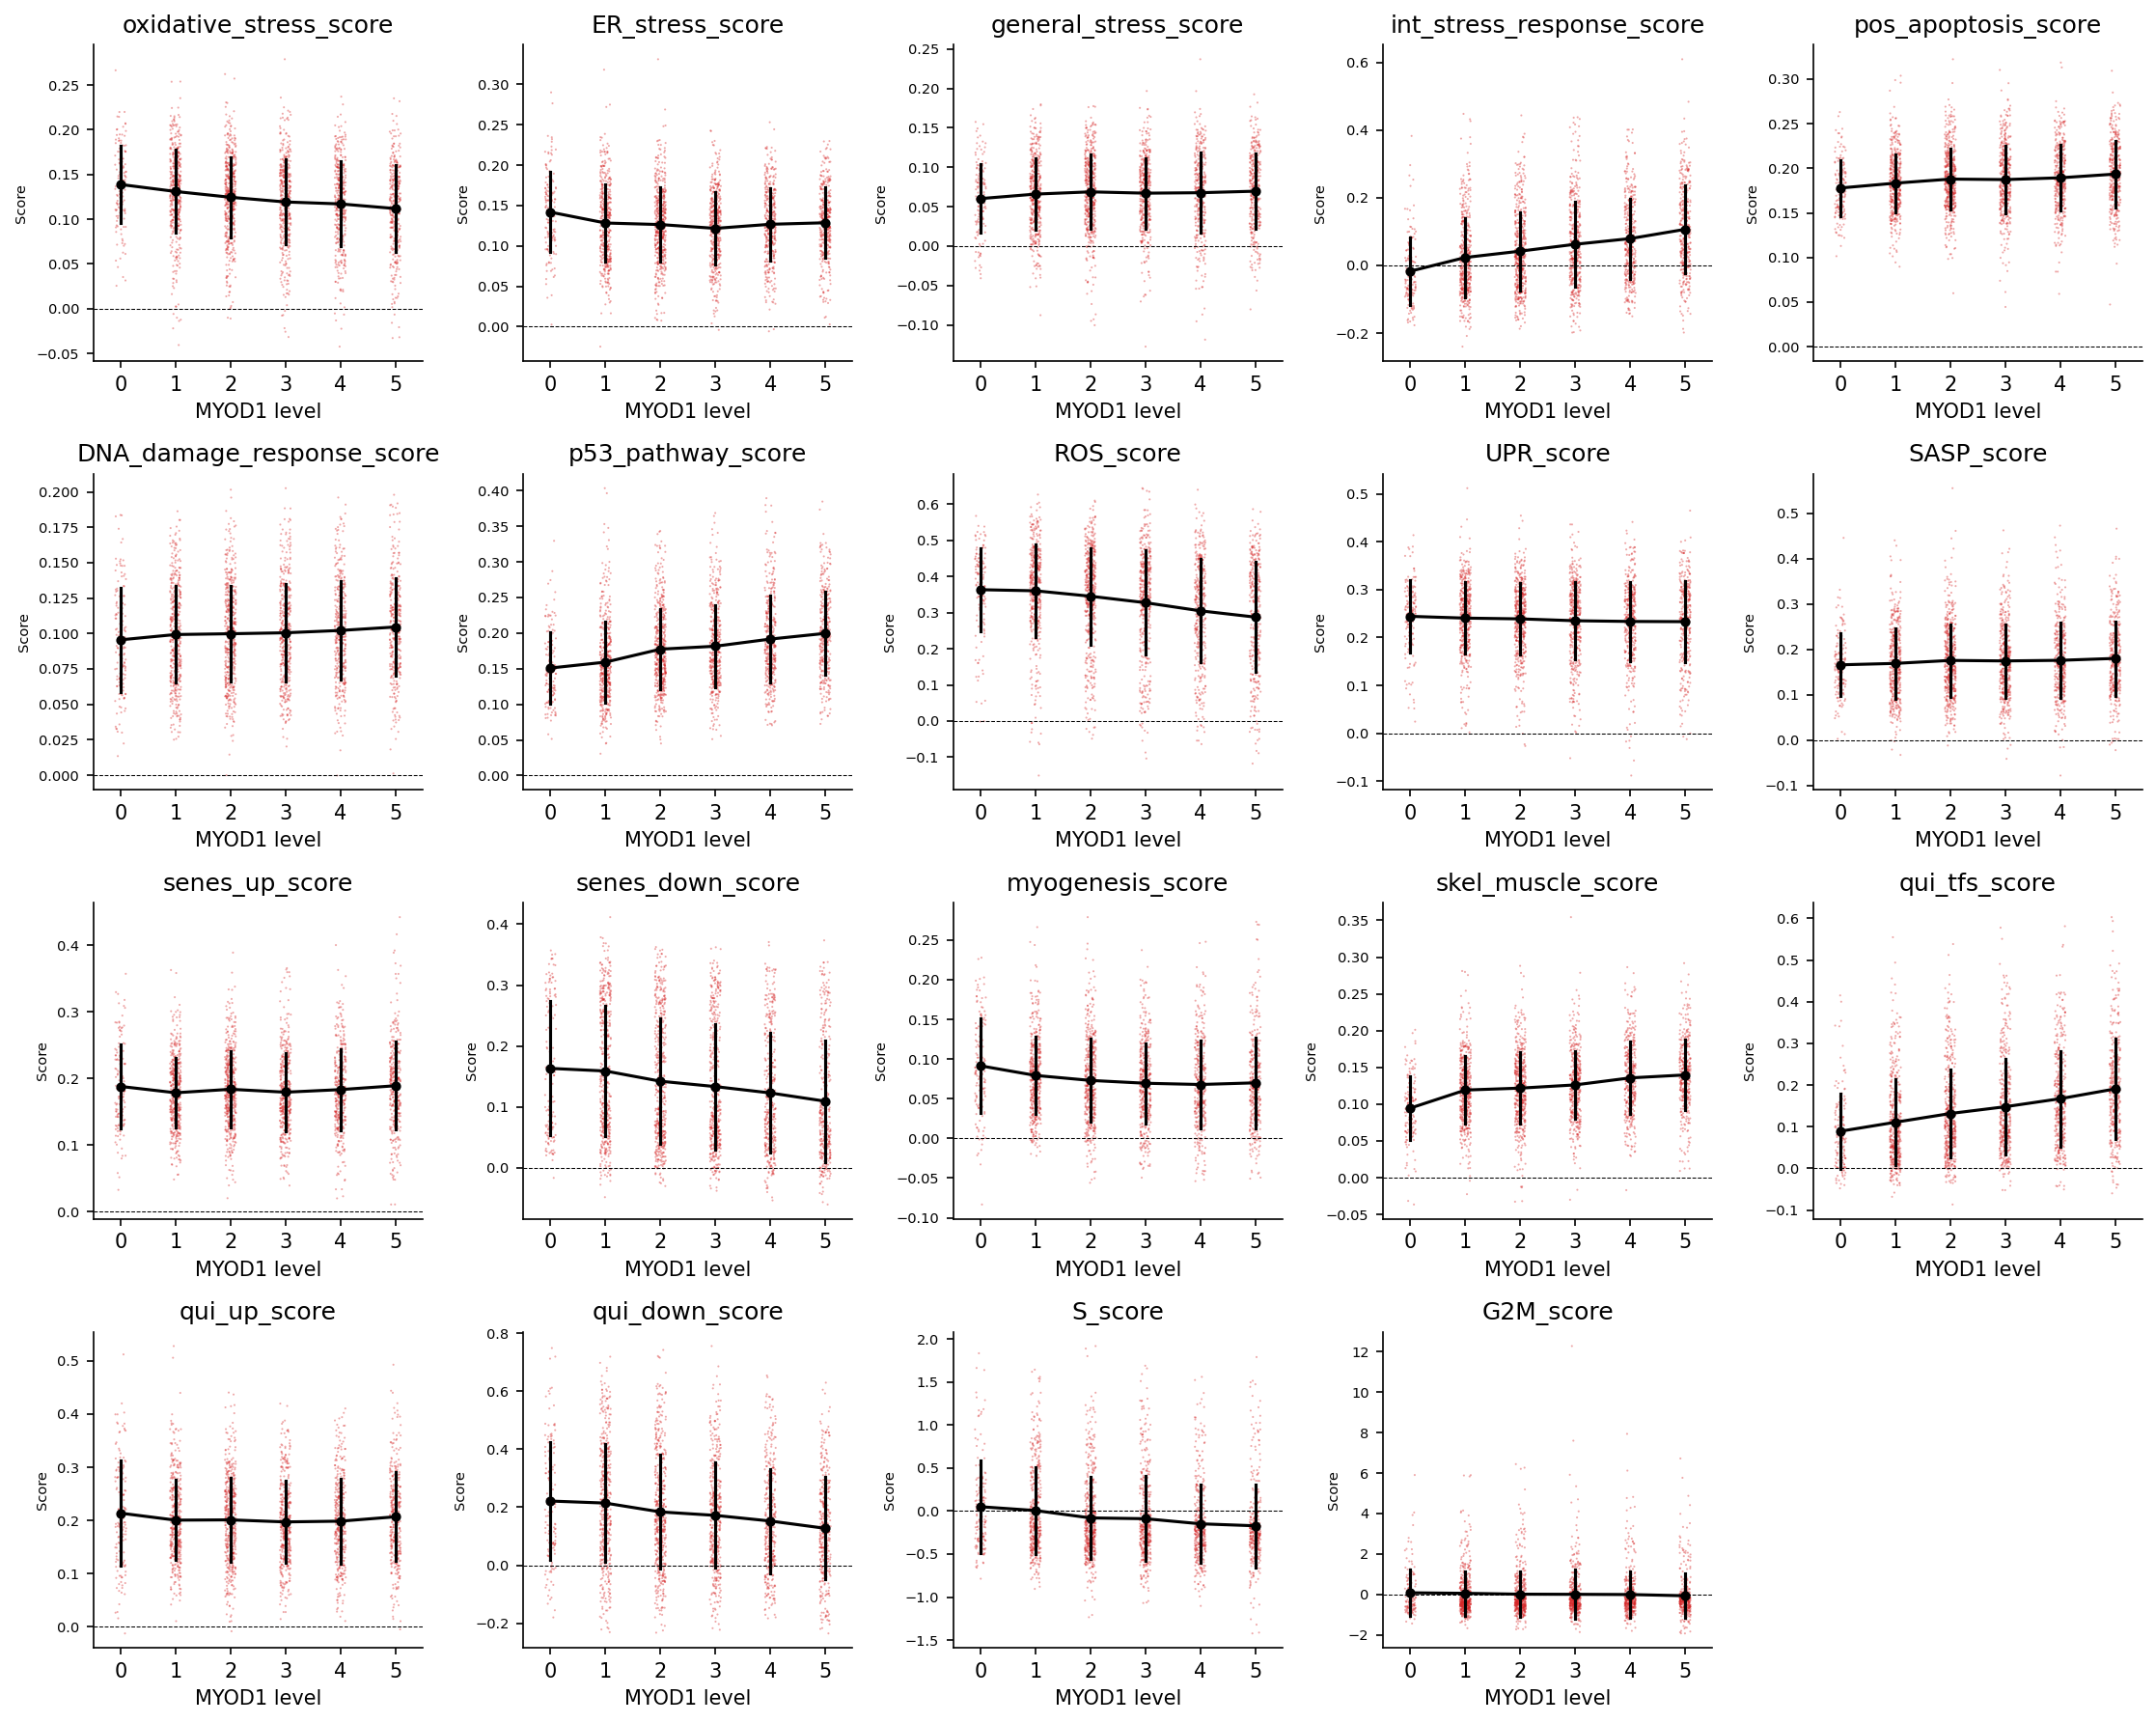

In [192]:
ncols = 5
nrows = math.ceil(len(scores_to_plot) / ncols)


fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*3, nrows*3), dpi=150)
axes = axes.flatten()

for i, score in enumerate(scores_to_plot):
    ax = axes[i]
    
    title = score
    
    sns.stripplot(
        data=pdf, 
        x="MYOD1_level", 
        y=score,
        alpha=.4, 
        legend=False, 
        s=1,
        edgecolor='none',
        ax=ax,
        color='tab:red',
        zorder=0,
    )
    sns.pointplot(
        pdf,
        x='MYOD1_level',
        y=score,
        errorbar='sd',
        linewidth=1.5,
        color='k',
        ax=ax,
    )
    
    ax.axhline(0, linestyle='--', linewidth=0.5, color='k', zorder=1)
    
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("MYOD1 level")
    ax.set_ylabel("Score", fontsize=7)
    ax.tick_params(axis='y', labelsize=7)
    sns.despine(ax=ax)
    
    
for ax in axes[len(scores_to_plot):]:
    ax.set_visible(False)
    
plt.tight_layout()
plt.show()

In [198]:
rho, p = spearmanr(pdf['MYOD1_level'], pdf['qui_tfs_score'])
print(f'{rho:.3f}', f'{p:.3e}')

rho, p = spearmanr(pdf['MYOD1_level'], pdf['skel_muscle_score'])
print(f'{rho:.3f}', f'{p:.3e}')

rho, p = spearmanr(pdf['MYOD1_level'], pdf['int_stress_response_score'])
print(f'{rho:.3f}', f'{p:.3e}')

0.275 1.973e-40
0.210 6.148e-24
0.270 5.889e-39


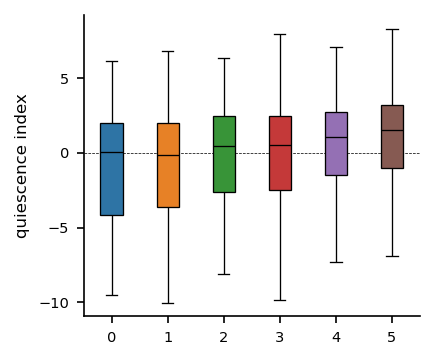

In [194]:
## quiescence index
qdf = adata.obs[['MYOD1_level', 'S_score', 'G2M_score', 'qui_tfs_score', 'qui_up_score', 'qui_down_score']].copy()

score_cols = qdf.columns[-5:]


# z-score normalize each score across all cells
for col in score_cols:
    mean = qdf[col].mean()
    std = qdf[col].std()
    qdf[col + '_z'] = (qdf[col] - mean) / std

# compute quiescence index per cell
qdf['QI_cell'] = (
    qdf['qui_tfs_score_z'] +
    qdf['qui_up_score_z'] -
    qdf['qui_down_score_z'] -
    qdf['S_score_z'] -
    qdf['G2M_score_z']
)

qdf.head()

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 3, 2.5

# cond_order = qi_cluster.index.tolist()

sns.boxplot(
    data=qdf,
    x='MYOD1_level',
    hue='MYOD1_level',
    # order=cond_order,
    y='QI_cell',
    width=0.4,
    linecolor='k',
    linewidth=0.63,
    # palette=mdata.uns['cluster_str_colors'],
    legend=False,
    saturation=0.8,
    showfliers=False,
    # flierprops={'markersize': 0.5, 'alpha': 0.5},
    zorder=1,
)

plt.axhline(0, linestyle='--', linewidth=0.35, color='k', zorder=0)

plt.ylabel('quiescence index', fontsize=8)
plt.xticks(fontsize=7)#, rotation=90)
plt.yticks(fontsize=7)
plt.xlabel("")

sns.despine()
plt.tight_layout()
plt.show() 

In [195]:
rho, p = spearmanr(qdf['MYOD1_level'], qdf['QI_cell'])
print(f'{rho:.3f}', f'{p:.3e}')

0.167 1.250e-15


In [ ]:
### could also do DEG between bins, run GSEA for these gene sets

In [199]:
sc.tl.rank_genes_groups(
    adata,
    groupby='MYOD1_level',
    method='wilcoxon',
    layer='log_norm',
    use_raw=False,
    pts=True,
    key_added='myod_level_deg',
)

ranking genes


... storing 'phase' as categorical


    finished (0:00:06)


In [200]:
deg_key = 'myod_level_deg'

deg = sc.get.rank_genes_groups_df(
    adata,
    group=None,
    key=deg_key,
)

deg['direction'] = np.where(deg['logfoldchanges'] > 0, 'up', 'down')
print(deg.shape)
deg.head()

mdf = deg[deg['pvals_adj'] < 0.05].copy()
print(mdf.shape)
mdf.head()

(110220, 9)
(2881, 9)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference,direction
0,0,PTN,7.820379,1.304520,5.266453e-15,4.837237e-11,0.846154,0.633996,up
1,0,CALR,6.997241,1.150682,2.610528e-12,9.591080e-09,0.790210,0.608428,up
2,0,ITGB1,6.934535,0.815583,4.075602e-12,1.178022e-08,0.944056,0.867424,up
3,0,THBS1,6.920866,1.082389,4.488924e-12,1.178022e-08,0.916084,0.787405,up
4,0,IFITM2,6.824783,0.896965,8.805834e-12,2.022040e-08,0.972028,0.911458,up


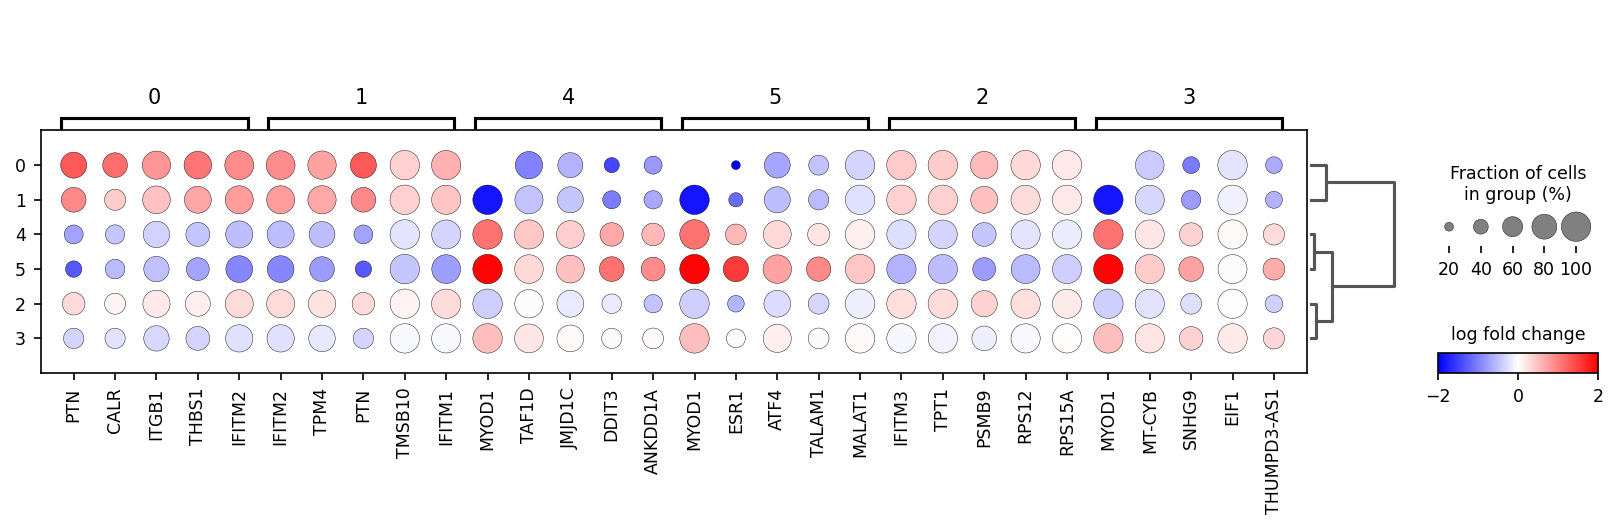

In [205]:
sc.pl.rank_genes_groups_dotplot(
    adata,
    n_genes=5,
    groupby='MYOD1_level',
    values_to_plot='logfoldchanges',
    # min_logfoldchange=0.5,
    key=deg_key,
    vmin=-2,
    vmax=2,
    cmap='bwr',
)